# RAVP Dataset EDA

Basic exploratory analysis for the RAVP dataset at `/my_workspace/Resume/RAVP_Dataset`.

This notebook covers:
- dataset integrity checks
- town-level summary tables
- per-frame target distributions
- pose and mask distributions
- detector coverage and score summaries
- a few qualitative RGB + mask examples


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

plt.style.use("ggplot")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


In [2]:
DATASET_ROOT = Path("/my_workspace/Resume/RAVP_Dataset")

SUMMARY_PATH = DATASET_ROOT / "collection_summary.json"
FRAMES_PATH = DATASET_ROOT / "frames.jsonl"
GT_PATH = DATASET_ROOT / "gt_poses.csv"
PRED_PATH = DATASET_ROOT / "pred_poses.csv"

for path in [SUMMARY_PATH, FRAMES_PATH, GT_PATH, PRED_PATH]:
    print(f"{path.name}: exists={path.exists()} size_mb={path.stat().st_size / (1024 ** 2):.2f}")

assert DATASET_ROOT.exists(), f"Dataset root not found: {DATASET_ROOT}"
assert GT_PATH.exists(), f"Missing GT CSV: {GT_PATH}"
assert FRAMES_PATH.exists(), f"Missing frames manifest: {FRAMES_PATH}"


collection_summary.json: exists=True size_mb=0.00
frames.jsonl: exists=True size_mb=18.96
gt_poses.csv: exists=True size_mb=30.05
pred_poses.csv: exists=True size_mb=27.51


In [3]:
with open(SUMMARY_PATH, "r") as handle:
    summary = json.load(handle)

frames_df = pd.read_json(FRAMES_PATH, lines=True)
gt_df = pd.read_csv(GT_PATH)
pred_df = pd.read_csv(PRED_PATH) if PRED_PATH.exists() else pd.DataFrame()

for df in [gt_df, pred_df]:
    if df.empty:
        continue
    numeric_cols = [
        "frame_id",
        "episode_id",
        "tick",
        "actor_id",
        "bbox_x1",
        "bbox_y1",
        "bbox_x2",
        "bbox_y2",
        "mask_area_px",
        "dx_m",
        "dy_m",
        "dz_m",
        "yaw_deg",
        "yaw_follow_deg",
        "follow_valid",
        "pose_score",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

frames_df.head()


,frame_id,episode_id,town,tick,rgb_path,accepted_target_count,predicted_target_count,accepted_actor_ids
0,0,0,Town01,244036,rgb/frame_000000.jpg,1,1,[7946]
1,1,0,Town01,244037,rgb/frame_000001.jpg,1,1,[7946]
2,2,0,Town01,244038,rgb/frame_000002.jpg,1,1,[7946]
3,3,0,Town01,244039,rgb/frame_000003.jpg,1,1,[7946]
4,4,0,Town01,244040,rgb/frame_000004.jpg,1,1,[7946]


## Headline Summary

In [4]:
headline = pd.Series(
    {
        "dataset_root": str(DATASET_ROOT),
        "configured_towns": len(summary.get("configured_towns", [])),
        "observed_towns": len(summary.get("towns", [])),
        "frames_manifest_rows": len(frames_df),
        "gt_rows": len(gt_df),
        "pred_rows": len(pred_df),
        "summary_total_frames": summary.get("total_frames"),
        "summary_total_gt_samples": summary.get("total_gt_samples"),
        "summary_total_pred_samples": summary.get("total_pred_samples"),
        "avg_gt_targets_per_frame": summary.get("avg_gt_targets_per_frame"),
        "avg_pred_targets_per_frame": summary.get("avg_pred_targets_per_frame"),
    }
)
headline.to_frame("value")


,value
dataset_root,/my_workspace/Resume/RAVP_Dataset
configured_towns,10
observed_towns,10
frames_manifest_rows,100000
gt_rows,133830
pred_rows,115970
summary_total_frames,100000
summary_total_gt_samples,133830
summary_total_pred_samples,115970
avg_gt_targets_per_frame,1.3383


In [5]:
integrity = pd.Series(
    {
        "unique_gt_sample_ids": gt_df["sample_id"].nunique(),
        "duplicate_gt_sample_ids": int(gt_df["sample_id"].duplicated().sum()),
        "unique_pred_sample_ids": pred_df["sample_id"].nunique() if not pred_df.empty else 0,
        "duplicate_pred_sample_ids": int(pred_df["sample_id"].duplicated().sum()) if not pred_df.empty else 0,
        "unique_gt_frames": gt_df["frame_id"].nunique(),
        "unique_pred_frames": pred_df["frame_id"].nunique() if not pred_df.empty else 0,
        "manifest_unique_frames": frames_df["frame_id"].nunique(),
        "missing_gt_rgb_files": int((~gt_df["rgb_path"].map(lambda p: (DATASET_ROOT / p).exists())).sum()),
        "missing_gt_mask_files": int((~gt_df["mask_path"].map(lambda p: (DATASET_ROOT / p).exists())).sum()),
    }
)
integrity.to_frame("value")


,value
unique_gt_sample_ids,133830
duplicate_gt_sample_ids,0
unique_pred_sample_ids,115970
duplicate_pred_sample_ids,0
unique_gt_frames,100000
unique_pred_frames,86048
manifest_unique_frames,100000
missing_gt_rgb_files,0
missing_gt_mask_files,0


## Town-Level EDA

In [6]:
gt_by_town = gt_df.groupby("town").agg(
    gt_samples=("sample_id", "count"),
    unique_frames=("frame_id", "nunique"),
    follow_valid_ratio=("follow_valid", "mean"),
    mean_dx_m=("dx_m", "mean"),
    mean_abs_dy_m=("dy_m", lambda s: s.abs().mean()),
    mean_abs_yaw_follow_deg=("yaw_follow_deg", lambda s: s.abs().mean()),
    mean_mask_area_px=("mask_area_px", "mean"),
)

if not pred_df.empty:
    pred_by_town = pred_df.groupby("town").agg(
        pred_samples=("sample_id", "count"),
        mean_pred_score=("pose_score", "mean"),
    )
    town_table = gt_by_town.join(pred_by_town, how="left")
else:
    town_table = gt_by_town.copy()

town_table["pred_coverage_vs_gt"] = (
    town_table["pred_samples"] / town_table["gt_samples"]
    if "pred_samples" in town_table.columns
    else np.nan
)
town_table = town_table.sort_values("gt_samples", ascending=False)
town_table.round(3)


,gt_samples,unique_frames,follow_valid_ratio,mean_dx_m,mean_abs_dy_m,mean_abs_yaw_follow_deg,mean_mask_area_px,pred_samples,mean_pred_score,pred_coverage_vs_gt
town,,,,,,,,,,
Town05_Opt,15920,10000,1.0,16.643,3.476,22.532,12356.340,15413,0.659,0.968
Town05,15440,10000,1.0,17.657,3.721,18.776,4399.075,15123,0.659,0.979
Town04_Opt,15124,10000,1.0,21.979,4.118,4.448,4395.036,14085,0.674,0.931
Town04,14751,10000,1.0,20.557,3.551,4.829,4611.038,14263,0.656,0.967
Town02,13447,10000,1.0,18.476,2.438,28.539,19129.323,10729,0.635,0.798
Town03_Opt,12908,10000,1.0,18.212,2.629,20.696,14143.079,12056,0.660,0.934
Town03,12135,10000,1.0,21.660,3.275,23.139,16916.691,10977,0.639,0.905
Town01,11829,10000,1.0,22.571,1.507,19.907,20424.603,9319,0.588,0.788
Town01_Opt,11281,10000,1.0,28.224,1.546,14.009,16915.812,7374,0.532,0.654


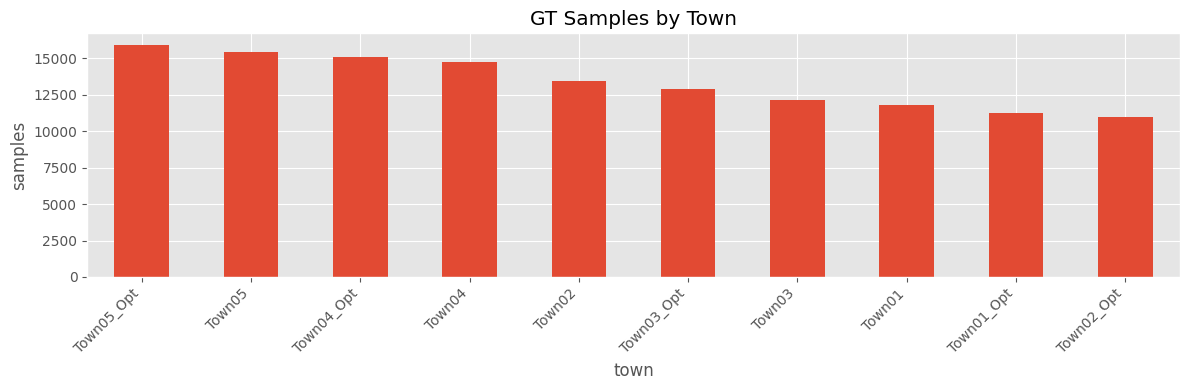

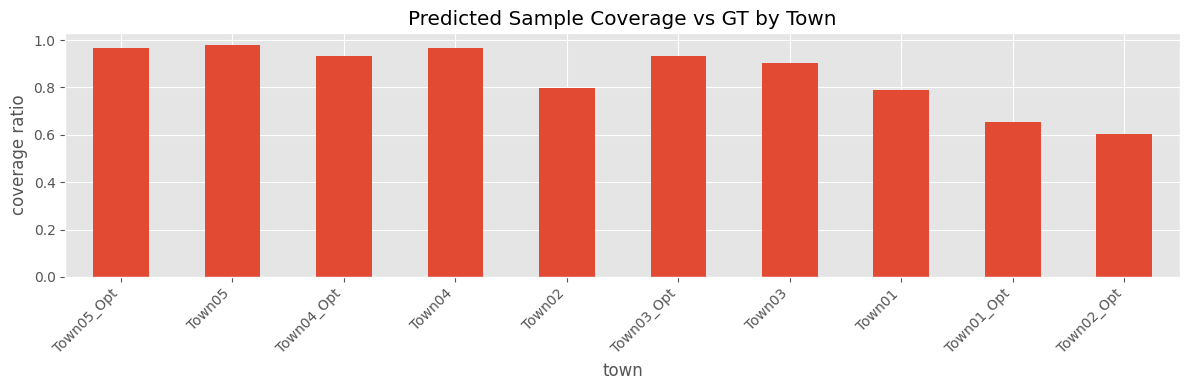

In [7]:
ax = town_table[["gt_samples"]].plot(kind="bar", figsize=(12, 4), legend=False)
ax.set_title("GT Samples by Town")
ax.set_ylabel("samples")
ax.set_xlabel("town")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if "pred_samples" in town_table.columns:
    ax = town_table[["pred_coverage_vs_gt"]].plot(kind="bar", figsize=(12, 4), legend=False)
    ax.set_title("Predicted Sample Coverage vs GT by Town")
    ax.set_ylabel("coverage ratio")
    ax.set_xlabel("town")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## Per-Frame Target Counts

In [8]:
gt_targets_per_frame = gt_df.groupby("frame_id").size().rename("gt_targets")
per_frame_df = gt_targets_per_frame.to_frame()

if not pred_df.empty:
    pred_targets_per_frame = pred_df.groupby("frame_id").size().rename("pred_targets")
    per_frame_df = per_frame_df.join(pred_targets_per_frame, how="left").fillna(0)
    per_frame_df["pred_targets"] = per_frame_df["pred_targets"].astype(int)

per_frame_df.describe().round(3)


,gt_targets,pred_targets
count,100000.000,100000.000
mean,1.338,1.160
std,0.644,0.766
min,1.000,0.000
25%,1.000,1.000
50%,1.000,1.000
75%,2.000,1.000
max,4.000,4.000


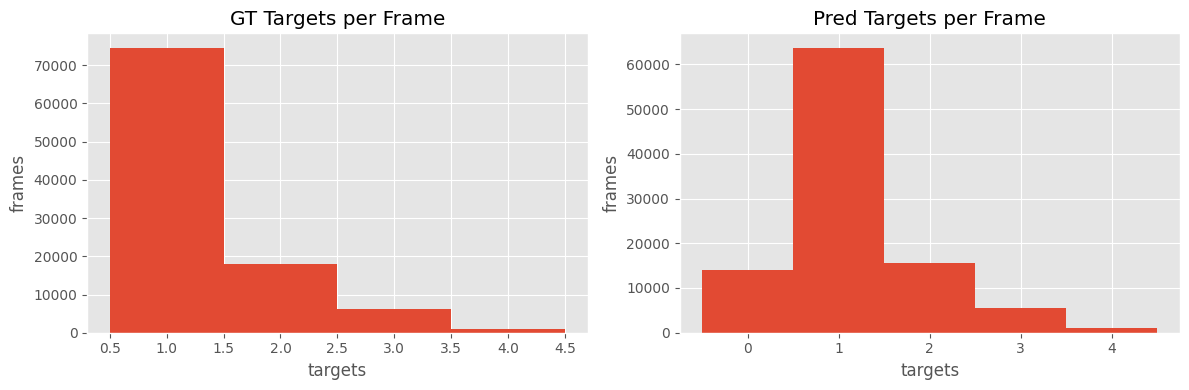

In [9]:
fig, axes = plt.subplots(1, 2 if "pred_targets" in per_frame_df.columns else 1, figsize=(12, 4))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

axes[0].hist(per_frame_df["gt_targets"], bins=np.arange(1, per_frame_df["gt_targets"].max() + 2) - 0.5)
axes[0].set_title("GT Targets per Frame")
axes[0].set_xlabel("targets")
axes[0].set_ylabel("frames")

if "pred_targets" in per_frame_df.columns:
    axes[1].hist(per_frame_df["pred_targets"], bins=np.arange(0, per_frame_df["pred_targets"].max() + 2) - 0.5)
    axes[1].set_title("Pred Targets per Frame")
    axes[1].set_xlabel("targets")
    axes[1].set_ylabel("frames")

plt.tight_layout()
plt.show()


## Pose and Mask Distributions

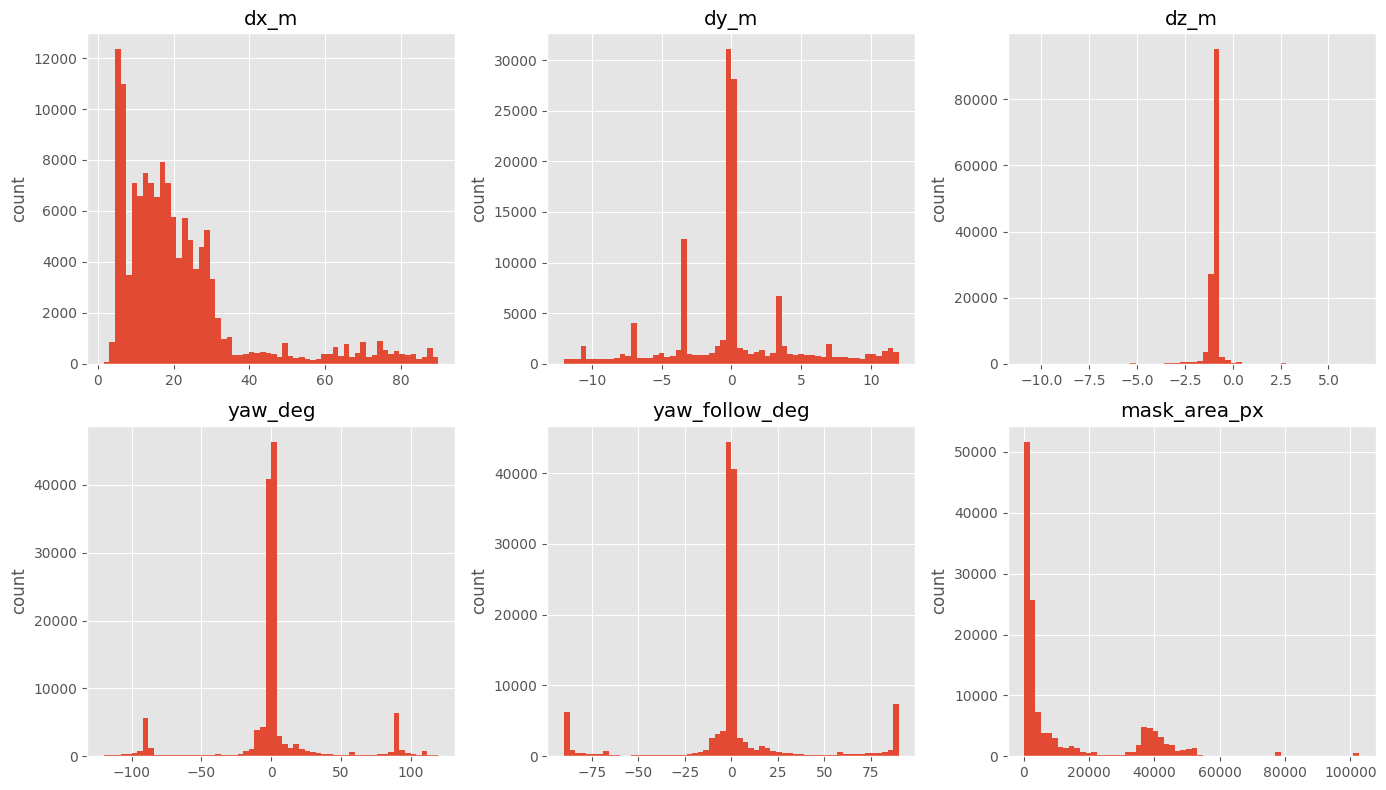

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].hist(gt_df["dx_m"], bins=60)
axes[0, 0].set_title("dx_m")

axes[0, 1].hist(gt_df["dy_m"], bins=60)
axes[0, 1].set_title("dy_m")

axes[0, 2].hist(gt_df["dz_m"], bins=60)
axes[0, 2].set_title("dz_m")

axes[1, 0].hist(gt_df["yaw_deg"], bins=60)
axes[1, 0].set_title("yaw_deg")

axes[1, 1].hist(gt_df["yaw_follow_deg"], bins=60)
axes[1, 1].set_title("yaw_follow_deg")

axes[1, 2].hist(gt_df["mask_area_px"], bins=60)
axes[1, 2].set_title("mask_area_px")

for ax in axes.ravel():
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()


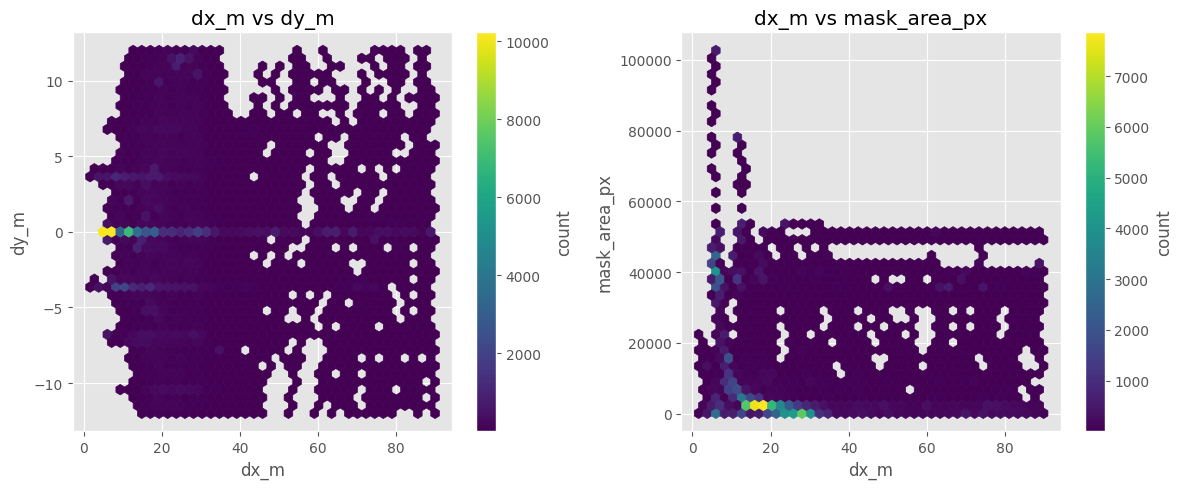

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

hb = axes[0].hexbin(gt_df["dx_m"], gt_df["dy_m"], gridsize=40, mincnt=1)
axes[0].set_title("dx_m vs dy_m")
axes[0].set_xlabel("dx_m")
axes[0].set_ylabel("dy_m")
fig.colorbar(hb, ax=axes[0], label="count")

hb = axes[1].hexbin(gt_df["dx_m"], gt_df["mask_area_px"], gridsize=40, mincnt=1)
axes[1].set_title("dx_m vs mask_area_px")
axes[1].set_xlabel("dx_m")
axes[1].set_ylabel("mask_area_px")
fig.colorbar(hb, ax=axes[1], label="count")

plt.tight_layout()
plt.show()


In [12]:
pose_summary = gt_df[["dx_m", "dy_m", "dz_m", "yaw_deg", "yaw_follow_deg", "mask_area_px"]].describe().T
pose_summary[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(3)


,mean,std,min,25%,50%,75%,max
dx_m,21.570,17.519,1.566,9.970,17.168,26.033,89.990
dy_m,-0.007,4.514,-11.999,-2.042,-0.002,0.773,11.998
dz_m,-0.969,0.427,-10.885,-0.986,-0.952,-0.885,6.588
yaw_deg,1.614,38.049,-119.993,-0.350,-0.001,0.503,119.981
yaw_follow_deg,1.584,35.405,-90.000,-0.350,-0.001,0.501,90.000
mask_area_px,12424.971,17773.612,122.000,1209.000,2558.000,15910.000,102616.000


## Detector Coverage and Error Summary

In [14]:
if pred_df.empty:
    print("pred_poses.csv not found or empty.")
else:
    matched_df = gt_df.merge(
        pred_df[["sample_id", "dx_m", "dy_m", "dz_m", "yaw_deg", "yaw_follow_deg", "pose_score"]],
        on="sample_id",
        how="left",
        suffixes=("_gt", "_pred"),
    )
    matched_df["matched"] = matched_df["dx_m_pred"].notna()
    matched_df["abs_dx_err_m"] = (matched_df["dx_m_pred"] - matched_df["dx_m_gt"]).abs()
    matched_df["abs_dy_err_m"] = (matched_df["dy_m_pred"] - matched_df["dy_m_gt"]).abs()
    matched_df["abs_dz_err_m"] = (matched_df["dz_m_pred"] - matched_df["dz_m_gt"]).abs()
    matched_df["abs_yaw_err_deg"] = (matched_df["yaw_deg_pred"] - matched_df["yaw_deg_gt"]).abs()
    matched_df["abs_yaw_follow_err_deg"] = (matched_df["yaw_follow_deg_pred"] - matched_df["yaw_follow_deg_gt"]).abs()

    detector_summary = pd.Series(
        {
            "gt_samples": len(matched_df),
            "matched_samples": int(matched_df["matched"].sum()),
            "coverage_ratio": float(matched_df["matched"].mean()),
            "mean_detector_score": float(matched_df.loc[matched_df["matched"], "pose_score_pred"].mean()),
            "mae_dx_m": float(matched_df.loc[matched_df["matched"], "abs_dx_err_m"].mean()),
            "mae_dy_m": float(matched_df.loc[matched_df["matched"], "abs_dy_err_m"].mean()),
            "mae_dz_m": float(matched_df.loc[matched_df["matched"], "abs_dz_err_m"].mean()),
            "mae_yaw_deg": float(matched_df.loc[matched_df["matched"], "abs_yaw_err_deg"].mean()),
            "mae_yaw_follow_deg": float(matched_df.loc[matched_df["matched"], "abs_yaw_follow_err_deg"].mean()),
        }
    )
    display(detector_summary.to_frame("value"))

    coverage_by_town = matched_df.groupby("town").agg(
        gt_samples=("sample_id", "count"),
        matched_samples=("matched", "sum"),
        coverage_ratio=("matched", "mean"),
        mean_score=("pose_score_pred", "mean"),
        mae_dx_m=("abs_dx_err_m", "mean"),
        mae_dy_m=("abs_dy_err_m", "mean"),
        mae_dz_m=("abs_dz_err_m", "mean"),
        mae_yaw_follow_deg=("abs_yaw_follow_err_deg", "mean"),
    )
    display(coverage_by_town.round(3))


,value
gt_samples,133830.000000
matched_samples,115970.000000
coverage_ratio,0.866547
mean_detector_score,0.639853
mae_dx_m,0.193380
mae_dy_m,0.110478
mae_dz_m,0.194697
mae_yaw_deg,22.952691
mae_yaw_follow_deg,10.605325


,gt_samples,matched_samples,coverage_ratio,mean_score,mae_dx_m,mae_dy_m,mae_dz_m,mae_yaw_follow_deg
town,,,,,,,,
Town01,11829,9319,0.788,0.588,0.198,0.130,0.095,17.911
Town01_Opt,11281,7374,0.654,0.532,0.281,0.199,0.132,11.292
Town02,13447,10729,0.798,0.635,0.185,0.140,0.079,19.238
Town02_Opt,10995,6631,0.603,0.608,0.211,0.169,0.098,8.056
Town03,12135,10977,0.905,0.639,0.193,0.102,0.438,8.598
Town03_Opt,12908,12056,0.934,0.660,0.197,0.098,0.121,9.445
Town04,14751,14263,0.967,0.656,0.187,0.076,0.280,4.033
Town04_Opt,15124,14085,0.931,0.674,0.171,0.090,0.223,4.327
Town05,15440,15123,0.979,0.659,0.244,0.087,0.198,14.116


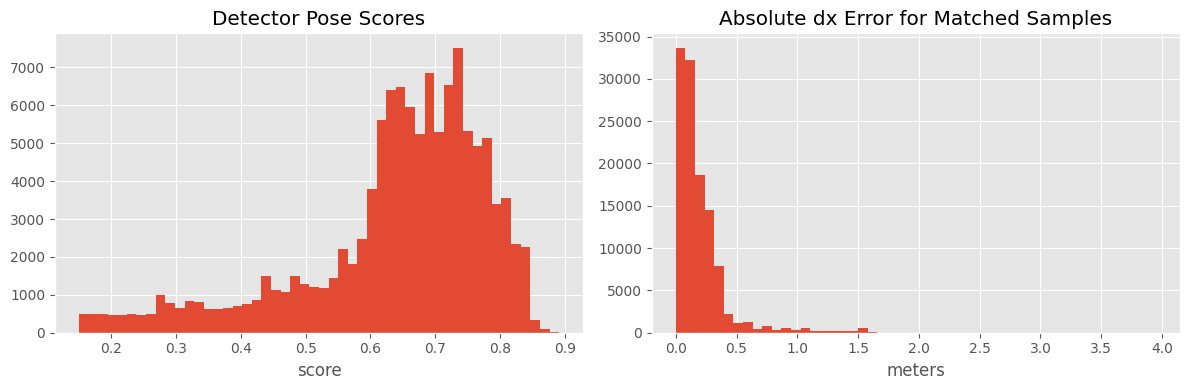

In [15]:
if not pred_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    matched_df["pose_score_pred"].dropna().hist(bins=50, ax=axes[0])
    axes[0].set_title("Detector Pose Scores")
    axes[0].set_xlabel("score")

    matched_df.loc[matched_df["matched"], "abs_dx_err_m"].hist(bins=50, ax=axes[1])
    axes[1].set_title("Absolute dx Error for Matched Samples")
    axes[1].set_xlabel("meters")

    plt.tight_layout()
    plt.show()


## Qualitative Examples

In [18]:
def show_samples(rows: pd.DataFrame, n: int = 6, random_state: int = 0) -> None:
    sample_rows = rows.sample(min(n, len(rows)), random_state=random_state)
    fig, axes = plt.subplots(
        len(sample_rows),
        2,
        figsize=(11, 4.8 * len(sample_rows)),
        constrained_layout=True,
    )
    if len(sample_rows) == 1:
        axes = np.array([axes])

    for axis_row, (_, row) in zip(axes, sample_rows.iterrows()):
        rgb = np.array(Image.open(DATASET_ROOT / row["rgb_path"]).convert("RGB"))
        mask = np.array(Image.open(DATASET_ROOT / row["mask_path"]).convert("L")) > 0

        overlay = rgb.copy()
        overlay[mask] = (
            0.6 * overlay[mask] + 0.4 * np.array([255, 64, 64])
        ).astype(np.uint8)

        axis_row[0].imshow(rgb)
        axis_row[0].set_title(
            "RGB\n"
            f"{row['town']} | frame {int(row['frame_id'])} | actor {int(row['actor_id'])}",
            fontsize=12,
            pad=10,
        )
        axis_row[0].axis("off")

        axis_row[1].imshow(overlay)
        axis_row[1].set_title(
            "Mask Overlay\n"
            f"dx={row['dx_m']:.2f} m | dy={row['dy_m']:.2f} m | yaw_f={row['yaw_follow_deg']:.1f} deg",
            fontsize=12,
            pad=10,
        )
        axis_row[1].axis("off")

    plt.show()


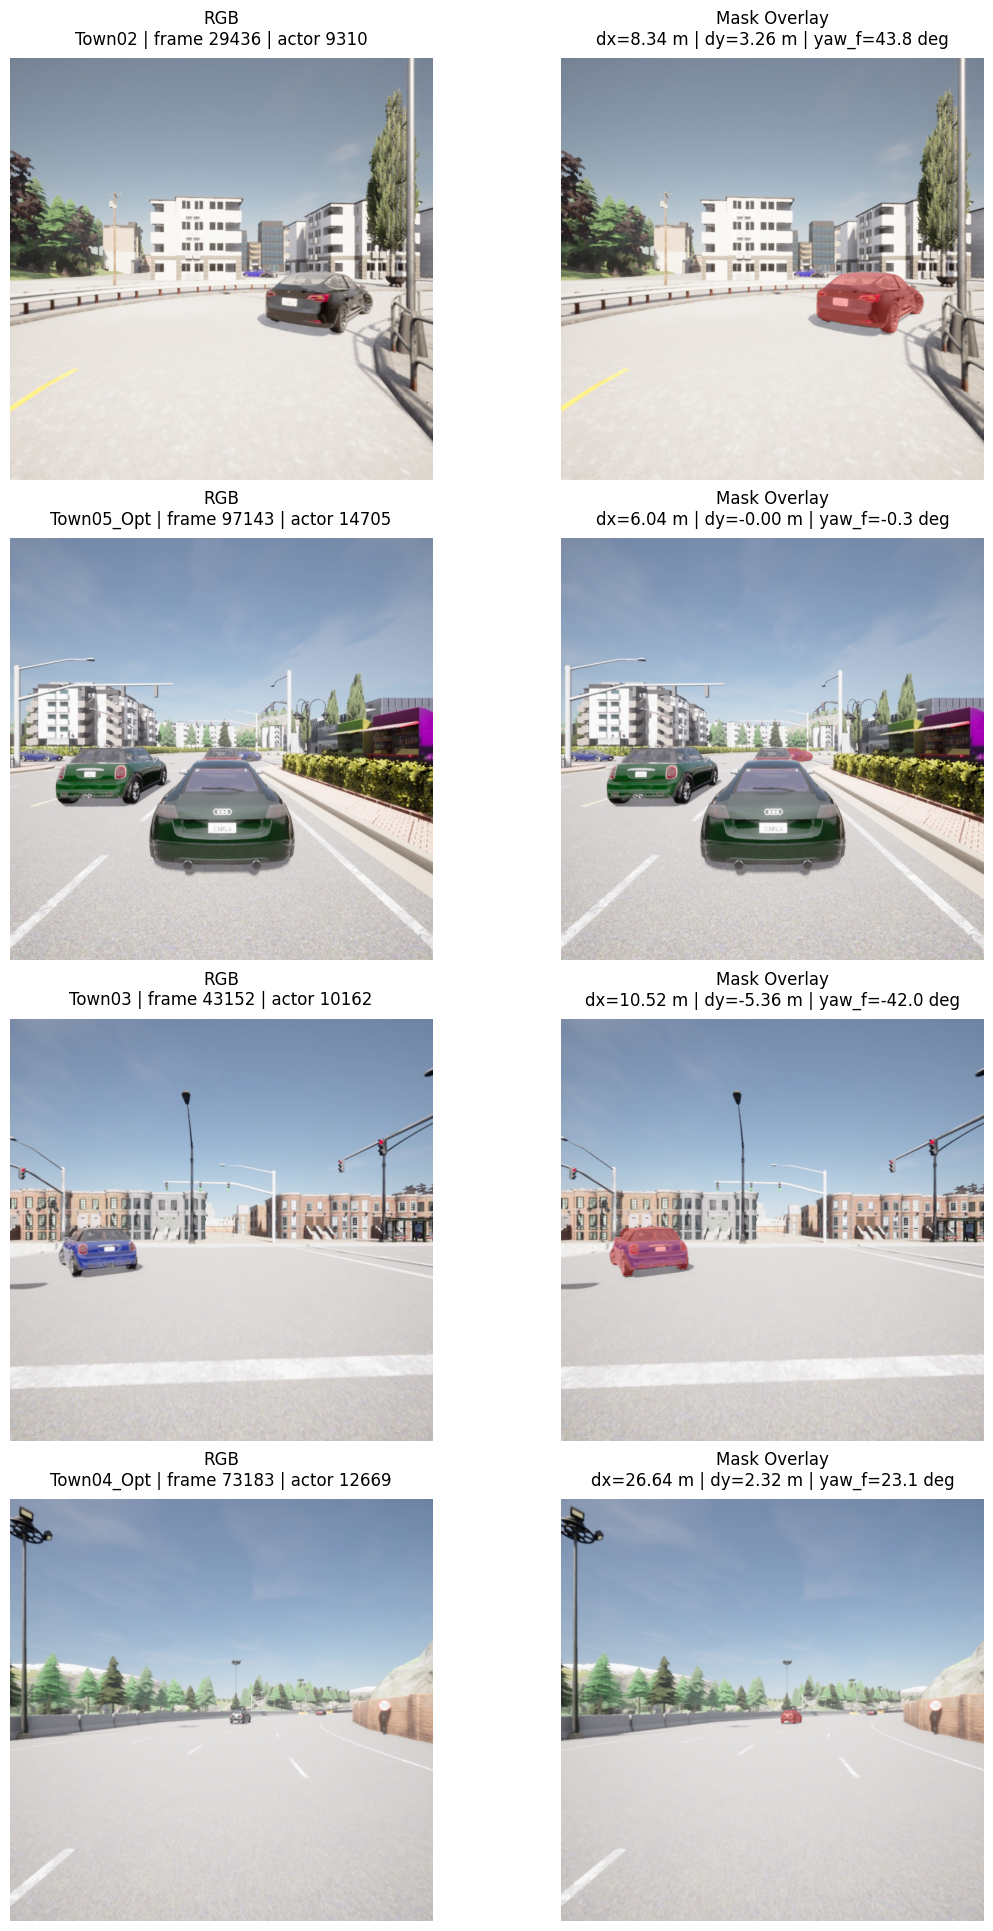

In [22]:
show_samples(gt_df, n=4, random_state=70)


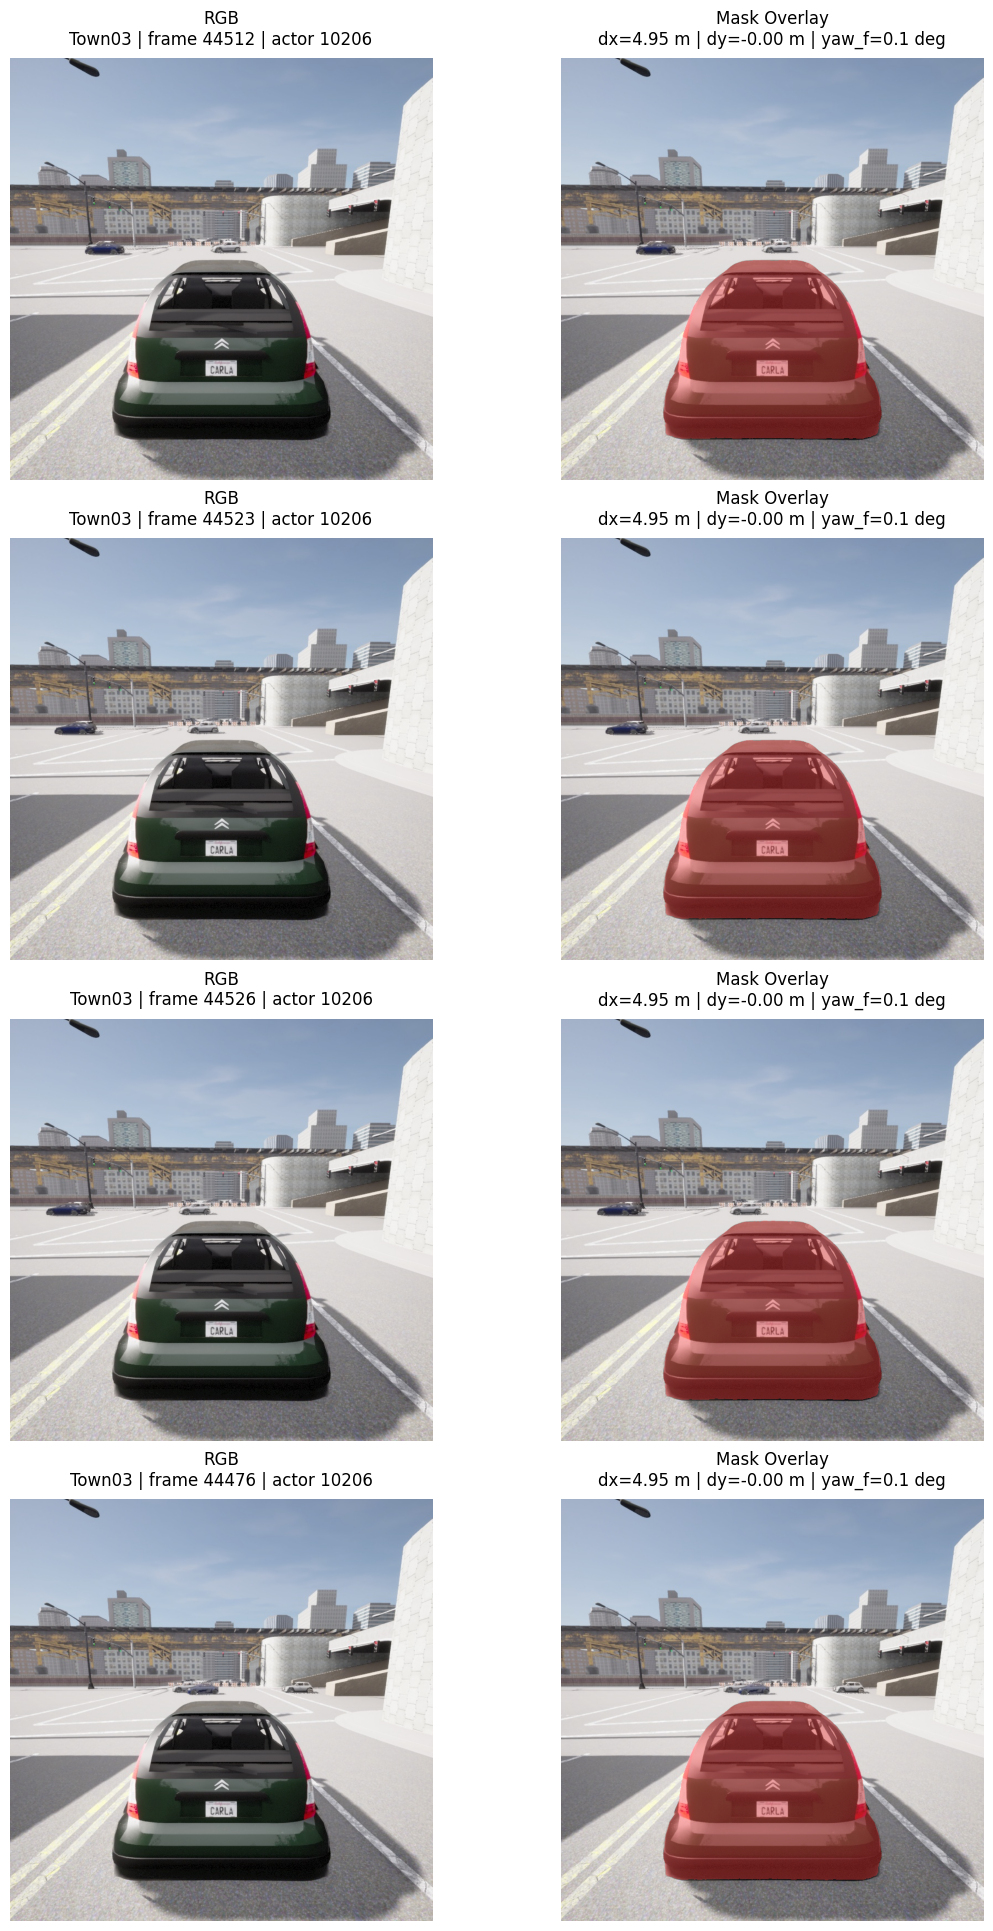

In [20]:
show_samples(gt_df.sort_values("mask_area_px").tail(4), n=4, random_state=0)
